# StormScope Nowcasting Over Wyoming

This notebook runs the **StormScope** nowcasting system from
[Earth2Studio](https://github.com/NVIDIA/earth2studio) and focuses the analysis on **Wyoming**:
a region squarely inside the famous "Hail Alley" corridor along the Colorado–Wyoming Front Range,
where high-based High Plains convection, terrain-driven initiation, and fast storm motion make
short-fuse nowcasting genuinely hard (and genuinely useful).

## What is StormScope?

StormScope is NVIDIA's observation-driven AI nowcasting model family for predicting the evolution
of storms, clouds, precipitation, and related mesoscale features over roughly the next 0–6 hours.
Instead of forecasting the full atmospheric state like FourCastNet, Atlas, or a traditional NWP
model, it forecasts what the observing systems themselves will see — primarily satellite imagery
and radar.

StormScope is an observation-to-observation generative AI nowcasting model that uses recent
satellite, radar, and lightning observations to predict the evolution of storm-scale weather over
the next several hours.

Two coupled prognostic models are used here:

| Model | State it forecasts | Conditioning | Grid |
|---|---|---|---|
| `StormScopeGOES` | 8 GOES ABI channels (`abi01c, abi02c, abi03c, abi07c, abi08c, abi09c, abi10c, abi13c`) | *pure obs* — none (`3km_10min` variant) | HRRR Lambert-conformal CONUS grid |
| `StormScopeMRMS` | MRMS radar `refc` (composite reflectivity), `refc_base` (base reflectivity), and `glm_density` (GLM lightning event density) | GOES ABI channels | same HRRR grid |

The GOES model advances the satellite scene forward in time; the MRMS+GLM model rides on top of
it, forecasting radar reflectivity and lightning **conditioned on the (predicted) satellite
imagery**. Both are autoregressive: each step's prediction is appended to a sliding window of
input frames and fed back in.

### In this notebook you will:

- Instantiate the StormScope GOES and MRMS+GLM models
- Build GOES, MRMS, and GLM data sources and assemble the initial condition
- Sanity-check the initial condition over Wyoming before spending GPU time
- Run the coupled autoregressive rollout and crop it to Wyoming
- Plot an hourly zoom grid over Wyoming
- Verify the forecast against observed MRMS reflectivity
- Export the Wyoming cut-out to NetCDF


## Installation and Setup

StormScope has its own dependency extra. Note two install quirks called out in the Earth2Studio
install guide:

- StormScope depends on **`natten`** (neighborhood attention), which can take a long time to
  compile from source.
- **`earth2grid`** must be installed manually for pip users (pinned commit below).

Uncomment and run once per environment.


In [11]:
#uv init --python=3.13
#uv add "earth2studio[data,stormscope] @ git+https://github.com/NVIDIA/earth2studio.git@0.18.0"
#uv add cartopy matplotlib tqdm python-dotenv

## Imports

The key Earth2Studio pieces we will need today:

- `earth2studio.data.GOES`: GOES ABI L1b/L2 CONUS imagery straight from the NOAA AWS bucket.
- `earth2studio.data.MRMS`: Multi-Radar Multi-Sensor reflectivity mosaics (`s3://noaa-mrms-pds`).
- `earth2studio.data.GOESGLMGrid`: GLM lightning events accumulated onto a 0.1° grid via 5-minute
  binning (`glm_density` = raw event counts per cell; the model applies `log1p` internally and
  bilinearly regrids onto its own grid).
- `earth2studio.data.fetch_data`: the standard helper that fetches a `(time, lead_time, variable)`
  block from any data source as a coordinate-labeled torch tensor.
- `earth2studio.models.px.StormScopeGOES` / `StormScopeMRMS`: the two prognostic models.


In [12]:
import os
from datetime import datetime, timezone, timedelta

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr
from dotenv import load_dotenv
from tqdm.auto import trange

load_dotenv()  # optional: pick up any credentials/cache settings from a .env file

from earth2studio.data import GOES, MRMS, GOESGLMGrid, fetch_data
from earth2studio.models.px.stormscope import (
    StormScopeBase,
    StormScopeGOES,
    StormScopeMRMS,
)

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

cuda NVIDIA GB200


## Global configuration

Region of interest, reproducibility seed, and the plotting/helper functions reused throughout the
notebook. Defined once here so every map later on shares the same styling.


In [13]:
# ---------------------------------------------------------------------------
# Wyoming region of interest
# ---------------------------------------------------------------------------
# Wyoming is almost exactly the box 41-45 N, 111.05-104.05 W. Coordinates use
# latitude in degrees north and longitude in [-180, 180].
WY = {
    "lat_min": 41.0,
    "lat_max": 45.0,
    "lon_min": -111.05,
    "lon_max": -104.05,
}

# Major Wyoming cities/towns to mark on the maps: name -> (lat, lon)
WY_CITIES = {
    "Cheyenne": (41.140, -104.820),
    "Laramie": (41.311, -105.591),
    "Casper": (42.867, -106.313),
    "Gillette": (44.291, -105.502),
    "Rock Springs": (41.587, -109.203),
    "Sheridan": (44.797, -106.956),
    "Jackson": (43.480, -110.762),
    "Evanston": (41.268, -110.963),
    "Riverton": (43.025, -108.380),
    "Cody": (44.526, -109.056),
}

# StormScope is generative, so fixing the random seed makes the generated forecast
# reproducible across repeated runs with the same inputs/model.
SEED = 1234
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------------------------
# Shared map projection and extents
# ---------------------------------------------------------------------------
proj_hrrr = ccrs.LambertConformal(
    central_longitude=262.5, central_latitude=38.5, standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)
CONUS_EXTENT = [-127.0, -65.0, 23.0, 50.0]
WY_EXTENT = [WY["lon_min"] - 0.5, WY["lon_max"] + 0.5, WY["lat_min"] - 0.5, WY["lat_max"] + 0.5]


def add_borders(ax):
    ax.coastlines(color="black", linewidth=1.0)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.8)
    ax.coastlines(color="white", linewidth=0.35)
    ax.add_feature(cfeature.STATES, edgecolor="white", linewidth=0.3)


def draw_wy_box(ax, **kw):
    lons = [WY["lon_min"], WY["lon_max"], WY["lon_max"], WY["lon_min"], WY["lon_min"]]
    lats = [WY["lat_min"], WY["lat_min"], WY["lat_max"], WY["lat_max"], WY["lat_min"]]
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), **kw)


def add_cities(ax, color="white", edge="black", fontsize=7, label=True):
    # Mark the Wyoming cities with a dot and (optionally) a name label
    for name, (lat, lon) in WY_CITIES.items():
        ax.plot(lon, lat, marker="o", markersize=4, markerfacecolor=color, markeredgecolor=edge,
                 markeredgewidth=0.8, linestyle="none", transform=ccrs.PlateCarree(), zorder=10)
        if label:
            ax.annotate(name, xy=(lon, lat), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                         xytext=(4, 3), textcoords="offset points", fontsize=fontsize, color=color,
                         path_effects=[pe.withStroke(linewidth=1.5, foreground=edge)], zorder=11)


def plot_goes_mrms(ax, lon, lat, ir, refc, title, fontsize=10):
    im_ir = ax.pcolormesh(lon, lat, ir, transform=ccrs.PlateCarree(), cmap="gray_r",
                           shading="auto", vmin=200, vmax=300)
    refc_masked = np.where(refc <= 5, np.nan, refc)
    im_refc = ax.pcolormesh(lon, lat, refc_masked, transform=ccrs.PlateCarree(), cmap="magma",
                             shading="auto", vmin=5, vmax=60)
    add_borders(ax)
    ax.set_title(title, fontsize=fontsize)
    return im_ir, im_refc


def add_batch_dim(x, coords):
    # Insert a leading batch dimension [B, T, L, C, H, W] if not already present.
    if x.dim() == 5:
        x = x.unsqueeze(0)
        coords = coords.copy()
        coords["batch"] = np.array([0])
        coords.move_to_end("batch", last=False)
    return x.to(torch.float32), coords


def wy_bbox(lat, lon):
    # Boolean mask + (row, col) slice selecting the Wyoming box on a 2D lat/lon grid.
    lon180 = np.where(lon > 180, lon - 360, lon)
    mask = (
        (lat >= WY["lat_min"]) & (lat <= WY["lat_max"])
        & (lon180 >= WY["lon_min"]) & (lon180 <= WY["lon_max"])
    )
    ys, xs = np.where(mask)
    sl = (slice(ys.min(), ys.max() + 1), slice(xs.min(), xs.max() + 1))
    return mask, sl

## Case configuration

Everything you'd want to tweak lives in this cell.

**Choosing the initialization time**: StormScope `3km_10min` is a pure observation-based
nowcasting model. It does NOT require an FCN3 / AIWP / NWP initialization state — instead it uses
recent observations (GOES, radar, lightning) and predicts their evolution forward in time. All
data sources here are public NOAA archives on AWS (GOES ABI, GOES GLM, MRMS), so any historical
date with satellite+radar coverage works. For near-real-time use, stay **~15–30 min** behind the
clock to let the MRMS and GLM files land in the buckets.

**GOES platform**: StormScope is trained against GOES-East CONUS scans. **GOES-19 replaced
GOES-16 as GOES-East in April 2025** — pick the satellite that matches your date (handled
automatically below).

**Forecast horizon**: `3km_10min` advances the forecast in 10-minute increments. A full 6-hour
nowcast is therefore `6 h * 60 min/h / 10 min = 36` forecast steps.


In [14]:
now_utc = datetime.now(timezone.utc)

# Observation availability buffer.
OBSERVATION_LAG_MINUTES = 20
latest_available = now_utc - timedelta(minutes=OBSERVATION_LAG_MINUTES)

# StormScope 3km_10min expects initialization on a 10-minute boundary. Earth2Studio
# data interfaces expect a naive datetime representing UTC rather than a
# timezone-aware datetime.
INIT_TIME = latest_available.replace(
    minute=(latest_available.minute // 10) * 10, second=0, microsecond=0,
).replace(tzinfo=None)

NOWCAST_HOURS = 6
STEP_MINUTES = 10
N_STEPS = NOWCAST_HOURS * 60 // STEP_MINUTES  # 36

MODEL_NAME = "3km_10min"

# GOES-19 became the operational GOES-East satellite in April 2025; use GOES-16 for
# historical cases before that transition.
GOES_SATELLITE = "goes19" if INIT_TIME >= datetime(2025, 4, 7) else "goes16"
SCAN_MODE = "C"

print("=" * 72)
print("StormScope Live Wyoming Nowcast")
print("=" * 72)
print(f"StormScope init time:      {INIT_TIME:%Y-%m-%d %H:%M:%S} UTC")
print(f"Forecast horizon:          {NOWCAST_HOURS} hours")
print(f"Forecast cadence:          {STEP_MINUTES} minutes")
print(f"Forecast steps:            {N_STEPS}")
print(f"StormScope model:          {MODEL_NAME}")
print(f"GOES satellite:            {GOES_SATELLITE}")
print(
    f"Region:                    Wyoming "
    f"({WY['lat_min']:.2f}-{WY['lat_max']:.2f} N, "
    f"{abs(WY['lon_min']):.2f}-{abs(WY['lon_max']):.2f} W)"
)
print("=" * 72)
if device.type != "cuda":
    print("\nWARNING: StormScope is a large diffusion model. CPU inference will be impractically slow.")

StormScope Live Wyoming Nowcast
StormScope init time:      2026-09-02 08:00:00 UTC
Forecast horizon:          6 hours
Forecast cadence:          10 minutes
Forecast steps:            36
StormScope model:          3km_10min
GOES satellite:            goes19
Region:                    Wyoming (41.00-45.00 N, 111.05-104.05 W)


## Load the models

Both models come out of the **same default package** (`StormScopeBase.load_default_package()`
— an NGC/Hugging Face registry download of roughly 3 GB of `.mdlus` expert weights per model, plus
grid/normalization sidecar files, cached locally after the first run).

Two important flags:

- `amp=True`: automatic mixed precision for the diffusion sampling loop.
- `compile=True`: `torch.compile` the network. First step pays compile latency; every later step
  is much faster. Disable both if you're debugging.

Conditioning wiring in the `3km_10min` configuration:

- **GOES model**: `conditioning_data_source=None`. It is *pure obs* — it forecasts the ABI
  channels from their own recent history (a warning about the missing conditioning source is
  expected and harmless, since we drive the coupled loop manually).
- **MRMS model**: `conditioning_data_source=GOES(...)` (used for the initial condition
  bookkeeping) and `glm_data_source=GOESGLMGrid(satellite="east")`. Because we roll out via
  `call_with_conditioning`, the GLM source is only used to fetch the *initial* GLM state; after
  that, lightning evolves autoregressively as part of the model state.


In [15]:
package = StormScopeBase.load_default_package()

# --- GOES nowcast model: pure-obs (no external conditioning) --------------------
model = StormScopeGOES.load_model(
    package=package,
    conditioning_data_source=None,   # pure-obs in the 3km_10min variant
    model_name=MODEL_NAME,
    amp=True,
    compile=True,
)
model = model.to(device)
model.eval()

# --- MRMS+GLM nowcast model: conditioned on GOES --------------------------------
model_mrms = StormScopeMRMS.load_model(
    package=package,
    conditioning_data_source=GOES(satellite=GOES_SATELLITE, scan_mode=SCAN_MODE),
    glm_data_source=GOESGLMGrid(satellite="east"),
    model_name=MODEL_NAME,
    amp=True,
    compile=True,
)
model_mrms = model_mrms.to(device)
model_mrms.eval()

print("GOES variants       :", StormScopeGOES.list_available_models(package))
print("MRMS variants       :", StormScopeMRMS.list_available_models(package))
print("GOES state variables:", list(model.variables))
print("MRMS state variables:", list(model_mrms.variables))
print("GLM channels        :", list(model_mrms.glm_variables))
print("Model grid          :", tuple(model.latitudes.shape))

# Model grid (shared by both models), used for every plot / crop below
lat_m = model.latitudes.detach().cpu().numpy()
lon_m = model.longitudes.detach().cpu().numpy()
lon_m = np.where(lon_m > 180, lon_m - 360, lon_m)

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9e89672c0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9e6813170>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9eb30ae70>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9f2faf2c0>


2026-09-02 01:28:18.613 | WARNING  | earth2studio.models.px.stormscope:__init__:193 - No conditioning data source was provided to StormScope; set the conditioning_data_source attribute of the model before running inference with iterator mode, or use the call_with_conditioning method.
GOES variants       : {'3km_10min': {'description': 'CONUS nowcasting - 3 km / 10 min (recommended)', 'deprecated': False}, '6km_1hr': {'description': '6 km / 60 min nearcasting (legacy)', 'deprecated': True}}
MRMS variants       : {'3km_10min': {'description': 'CONUS MRMS+GLM nowcasting - 3 km / 10 min (recommended)', 'deprecated': False}, '6km_1hr': {'description': '6 km / 60 min MRMS nearcasting (legacy)', 'deprecated': True}}
GOES state variables: ['abi01c', 'abi02c', 'abi03c', 'abi07c', 'abi08c', 'abi09c', 'abi10c', 'abi13c']
MRMS state variables: ['refc', 'refc_base', 'glm_density']
GLM channels        : ['glm_density']
Model grid          : (1024, 1792)


## Initial conditions and regridding

The `3km_10min` variant is a **sliding-window** model: it consumes 6 input timesteps at 10-minute
spacing (encoded in `model.input_coords()["lead_time"]` as negative offsets from the init time)
and predicts one step ahead. `fetch_data` pulls exactly that window from the GOES archive.

Data stays on the **native GOES fixed-grid**; we only need to register an *input interpolator*
(GOES grid → model grid) once, and the model regrids internally on every call.

A warning about invalid gridpoints after interpolation is expected: the GOES CONUS sector doesn't
perfectly cover every corner of the HRRR grid (edges are filled with a constant and masked out by
`valid_mask`).

### Assemble the MRMS + GLM initial state

The MRMS model's state is `[refc, refc_base, glm_density]`. Because we drive the coupled rollout
ourselves with `call_with_conditioning`, **we own the full initial state** and assemble it
manually:

1. Fetch the radar channels (`refc`, `refc_base`) from **MRMS** over the same 6-frame window and
   regrid them onto the model grid (nearest-neighbor, via the registered input interpolator).
2. Fetch the **GLM** lightning window with `model_mrms.fetch_glm` — this reads the raw GLM L2
   LCFA event files, bins them into 5-minute counts on a 0.1° grid, and **bilinearly** regrids
   onto the model grid (lightning uses bilinear, unlike the nearest-neighbor radar/satellite
   path). Counts are physical; the model applies `log1p` internally.
3. Concatenate radar + GLM along the variable axis in the model's `variables` order (radar first,
   GLM last), and rewrite the coords to describe the model's `y/x` grid.

We also register a *conditioning* interpolator (GOES grid → model grid) since this model is
conditioned on satellite imagery.


In [16]:
start_date = [np.datetime64(INIT_TIME)]

goes = GOES(satellite=GOES_SATELLITE, scan_mode=SCAN_MODE)
goes_lat, goes_lon = GOES.grid(satellite=GOES_SATELLITE, scan_mode=SCAN_MODE)

# Register the GOES-grid -> model-grid interpolator (nearest-neighbor)
model.build_input_interpolator(goes_lat, goes_lon)

in_coords = model.input_coords()
variables = in_coords["variable"]
print("Input lead-time window:", in_coords["lead_time"].astype("timedelta64[m]"))

# Fetch the 6-frame ABI observation window on the native GOES grid
x, x_coords = fetch_data(
    goes,
    time=start_date,
    variable=np.array(variables),
    lead_time=in_coords["lead_time"],
    device=device,
)
print("GOES IC tensor:", tuple(x.shape), "| dims:", list(x_coords.keys()))

2026-09-02 01:28:29.504 | WARNING  | earth2studio.models.px.stormscope:build_input_interpolator:643 - Some input gridpoints are invalid after interpolation. This may be expected if the input data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (0.0).
Input lead-time window: [-50 -40 -30 -20 -10   0]


Fetching GOES data:   0%|          | 0/1 [00:01<?, ?it/s]

2026-09-02 01:28:33.133 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes19/ABI-L2-MCMIPC/2026/245/07/OR_ABI-L2-MCMIPC-M6_G19_s20262450711171_e20262450713550_c20262450714059.nc


Fetching GOES data: 100%|██████████| 1/1 [00:02<00:00,  2.27s/it]
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9f2fd93a0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xfffa129fe350>, 1704500.240881721)])']
connector: <aiohttp.connector.TCPConnector object at 0xfff9e907d460>
Fetching GOES data:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-02 01:28:34.133 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes19/ABI-L2-MCMIPC/2026/245/07/OR_ABI-L2-MCMIPC-M6_G19_s20262450721171_e20262450723550_c20262450724064.nc


...

2026-09-02 01:28:36.908 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes19/ABI-L2-MCMIPC/2026/245/07/OR_ABI-L2-MCMIPC-M6_G19_s20262450751171_e20262450753550_c20262450754059.nc


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9f2e53d10>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9e833b770>
Fetching GOES data: 100%|██████████| 1/1 [00:06<00:00,  6.53s/it]
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9f1880da0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xfff9e8971b70>, 1704509.61553574)])']
connector: <aiohttp.connector.TCPConnector object at 0xfff9ebe5ade0>
Fetching GOES data:   0%|          | 0/1 [00:01<?, ?it/s]

2026-09-02 01:28:45.607 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes19/ABI-L2-MCMIPC/2026/245/08/OR_ABI-L2-MCMIPC-M6_G19_s20262450801171_e20262450803550_c20262450804058.nc


Fetching GOES data: 100%|██████████| 1/1 [00:06<00:00,  6.94s/it]


GOES IC tensor: (1, 6, 8, 1500, 2500) | dims: ['time', 'lead_time', 'variable', 'y', 'x']


In [17]:
mrms = MRMS()
mrms_in_coords = model_mrms.input_coords()

# Radar channels = everything in the state that is not a GLM channel
radar_vars = np.array(
    [v for v in model_mrms.variables if v not in set(model_mrms.glm_variables)]
)

x_radar, x_coords_radar = fetch_data(
    mrms,
    time=start_date,
    variable=radar_vars,
    lead_time=mrms_in_coords["lead_time"],
    device=device,
)

# Interpolators: radar input (nearest-neighbor) + GOES conditioning; the GLM
# bilinear interpolator is built lazily inside fetch_glm.
model_mrms.build_input_interpolator(x_coords_radar["lat"], x_coords_radar["lon"])
model_mrms.build_conditioning_interpolator(goes_lat, goes_lon)

# Regrid radar onto the model grid
x_radar = model_mrms.input_interp(x_radar)

# Fetch + bilinearly regrid the GLM observation window
glm_coords = mrms_in_coords.copy()
glm_coords["time"] = np.array(start_date)
x_glm, _ = model_mrms.fetch_glm(glm_coords, device=device)

# Stack into the full [refc, refc_base, glm_density] state, dims [T, L, C, H, W]
x_mrms = torch.cat([x_radar, x_glm], dim=2).to(dtype=torch.float32)

# Rewrite coords for the model grid
x_coords_mrms = x_coords_radar.copy()
x_coords_mrms["variable"] = np.array(model_mrms.variables)
del x_coords_mrms["lat"], x_coords_mrms["lon"]
x_coords_mrms["y"] = model_mrms.y
x_coords_mrms["x"] = model_mrms.x

print("GOES IC tensor       :", tuple(x.shape), "| dims:", list(x_coords.keys()))
print("MRMS+GLM IC tensor   :", tuple(x_mrms.shape), "| dims:", list(x_coords_mrms.keys()))

Fetching MRMS data:   0%|          | 0/2 [00:02<?, ?it/s]

2026-09-02 01:28:53.860 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedBaseReflectivityQC_00.50/20260902/MRMS_MergedBaseReflectivityQC_00.50_20260902-071016.grib2.gz


Fetching MRMS data:  50%|█████     | 1/2 [00:04<00:04,  4.36s/it]

2026-09-02 01:28:56.183 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20260902/MRMS_MergedReflectivityQCComposite_00.50_20260902-071040.grib2.gz


Fetching MRMS data: 100%|██████████| 2/2 [00:06<00:00,  3.33s/it]
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfffa128db770>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xfff9f1747c40>, 1704520.957130427), (<aiohttp.client_proto.ResponseHandler object at 0xfff9f1746e40>, 1704523.27841481)])']
connector: <aiohttp.connector.TCPConnector object at 0xfffa128dade0>
Fetching MRMS data:   0%|          | 0/2 [00:00<?, ?it/s]

...

2026-09-02 01:30:08.484 | INFO     | earth2studio.data.goes_glm:fetch:346 - [earth2studio.data.goes_glm] discovered 17 unique GLM files across 1 requested times


Listing GLM L2 LCFA prefixes: 100%|██████████| 2/2 [00:01<00:00,  1.08it/s]


2026-09-02 01:30:16.119 | INFO     | earth2studio.data.goes_glm:fetch:346 - [earth2studio.data.goes_glm] discovered 17 unique GLM files across 1 requested times


Fetching GLM L2 LCFA files: 100%|██████████| 17/17 [00:04<00:00,  4.17it/s]


GOES IC tensor       : (1, 6, 8, 1500, 2500) | dims: ['time', 'lead_time', 'variable', 'y', 'x']
MRMS+GLM IC tensor   : (1, 6, 3, 1024, 1792) | dims: ['time', 'lead_time', 'variable', 'y', 'x']


## Sanity-check the initial condition over Wyoming

Before burning GPU-minutes on a rollout, always eyeball the analysis frame over your region:
clean-IR brightness temperature (`abi13c`, cold tops = deep convection) and composite reflectivity.
If the Wyoming window looks blank at your chosen init time, pick a different (stormier) date — the
model can only nowcast storms that exist or are initiating in the observations.


GOES: (1, 1, 6, 8, 1500, 2500) | MRMS+GLM: (1, 1, 6, 3, 1024, 1792)


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9d44187d0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9f1858e90>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9dc42f2c0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfffa12a7b170>


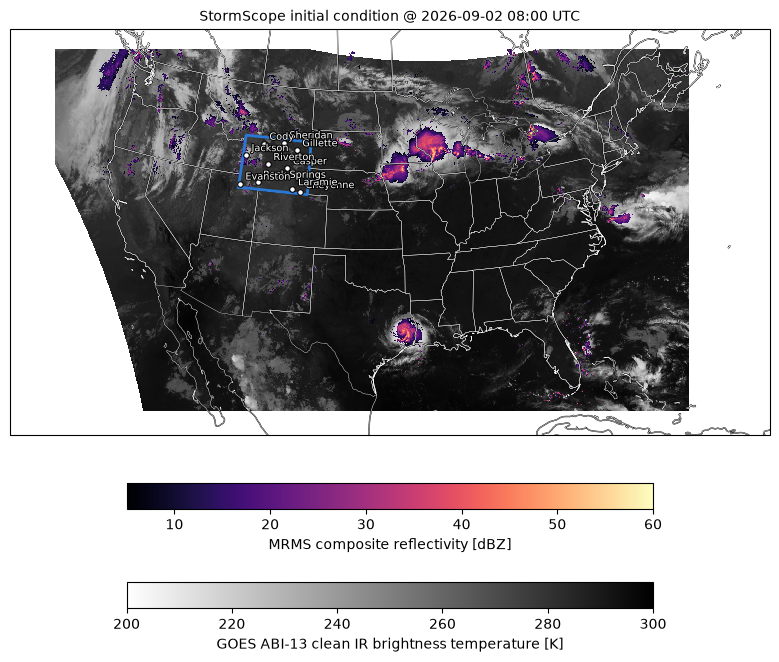

In [18]:
abi13_idx = list(model.variables).index("abi13c")
refc_idx = list(model_mrms.variables).index("refc")

# Add the batch dimension [B, T, L, C, H, W]; B>1 would give an ensemble
x, x_coords = add_batch_dim(x, x_coords)
x_mrms, x_coords_mrms = add_batch_dim(x_mrms, x_coords_mrms)
print("GOES:", tuple(x.shape), "| MRMS+GLM:", tuple(x_mrms.shape))

# Interpolate GOES input onto the model grid for plotting
x_on_grid = model.input_interp(x)
ir_ic = x_on_grid[0, -1, -1, abi13_idx].detach().cpu().numpy()
refc_ic = x_mrms[0, -1, -1, refc_idx].detach().cpu().numpy()

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=proj_hrrr)
ax.set_extent(CONUS_EXTENT, ccrs.PlateCarree())

im_ir, im_refc = plot_goes_mrms(
    ax, lon_m, lat_m, ir_ic, refc_ic,
    f"StormScope initial condition @ {INIT_TIME:%Y-%m-%d %H:%M} UTC",
)

# Highlight Wyoming
draw_wy_box(ax, color="#2a78d6", linewidth=2.0)
add_cities(ax, label=True)

plt.colorbar(im_ir, ax=ax, orientation="horizontal", pad=0.03, shrink=0.45,
             label="GOES ABI-13 clean IR brightness temperature [K]")
plt.colorbar(im_refc, ax=ax, orientation="horizontal", pad=0.09, shrink=0.45,
             label="MRMS composite reflectivity [dBZ]")

plt.tight_layout()
plt.savefig("outputs/conus_initial_condition.png", dpi=150, bbox_inches="tight")
plt.show()

## Coupled rollout over Wyoming

Each step: the GOES model advances the satellite state, then the MRMS+GLM model advances the
radar/lightning state conditioned on the *current* GOES state. Predictions are archived on the
model grid, cropped to the Wyoming bounding box with `wy_bbox`.


In [19]:
wy_mask, wy_slice = wy_bbox(lat_m, lon_m)
wy_mask_crop = wy_mask[wy_slice]
wy_lat = lat_m[wy_slice]
wy_lon = lon_m[wy_slice]
print(f"Wyoming box: {wy_mask.sum()} model grid points")

glm_idx = list(model_mrms.variables).index("glm_density")

y, y_coords = x, x_coords
y_mrms, y_coords_mrms = x_mrms, x_coords_mrms

# Per-step Wyoming archives: [step, H_wy, W_wy] (batch member 0)
wy_ir, wy_refc, wy_glm = [], [], []
valid_times = []

with torch.inference_mode():
    for step_idx in trange(N_STEPS, desc="Forecast steps"):
        # 1) GOES prognostic step
        y_pred, y_pred_coords = model(y, y_coords)

        # 2) MRMS+GLM step conditioned on GOES
        y_mrms_pred, y_coords_mrms_pred = model_mrms.call_with_conditioning(
            y_mrms, y_coords_mrms, conditioning=y, conditioning_coords=y_coords
        )

        # NaN-mask invalid gridpoints, then archive the Wyoming crop
        ir_full = torch.where(model.valid_mask, y_pred[0, 0, 0, abi13_idx], torch.nan)
        refc_full = torch.where(model_mrms.valid_mask, y_mrms_pred[0, 0, 0, refc_idx], torch.nan)
        glm_full = torch.where(model_mrms.valid_mask, y_mrms_pred[0, 0, 0, glm_idx], torch.nan)

        wy_ir.append(ir_full.detach().cpu().numpy()[wy_slice])
        wy_refc.append(refc_full.detach().cpu().numpy()[wy_slice])
        wy_glm.append(glm_full.detach().cpu().numpy()[wy_slice])

        valid_times.append(
            np.datetime64(INIT_TIME) + (step_idx + 1) * np.timedelta64(STEP_MINUTES, "m")
        )

        # 3) Slide the input windows forward
        y, y_coords = model.next_input(y_pred, y_pred_coords, y, y_coords)
        y_mrms, y_coords_mrms = model_mrms.next_input(
            y_mrms_pred, y_coords_mrms_pred, y_mrms, y_coords_mrms
        )

wy_ir = np.stack(wy_ir)      # [N_STEPS, H_wy, W_wy]
wy_refc = np.stack(wy_refc)
wy_glm = np.stack(wy_glm)
valid_times = np.array(valid_times)
print("Wyoming forecast stacks:", wy_refc.shape)

Wyoming box: 28320 model grid points


Forecast steps: 100%|██████████| 36/36 [34:39<00:00, 57.78s/it]

Wyoming forecast stacks: (36, 168, 205)


In [49]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.weight": "bold",           # default text (ax.text, annotations)
    "axes.titleweight": "bold",      # per-panel titles
    "axes.labelweight": "bold",      # x/y axis labels (colorbar label uses this)
    "figure.titleweight": "bold",    # fig.suptitle
})

## Hourly Wyoming zoom: forecast reflectivity on forecast IR

Major towns (Cheyenne, Laramie, Casper, Gillette, Rock Springs, Sheridan, Jackson, Evanston,
Riverton, Cody) are marked for orientation. The rollout advances every 10 minutes; here we sample
one panel per hour.


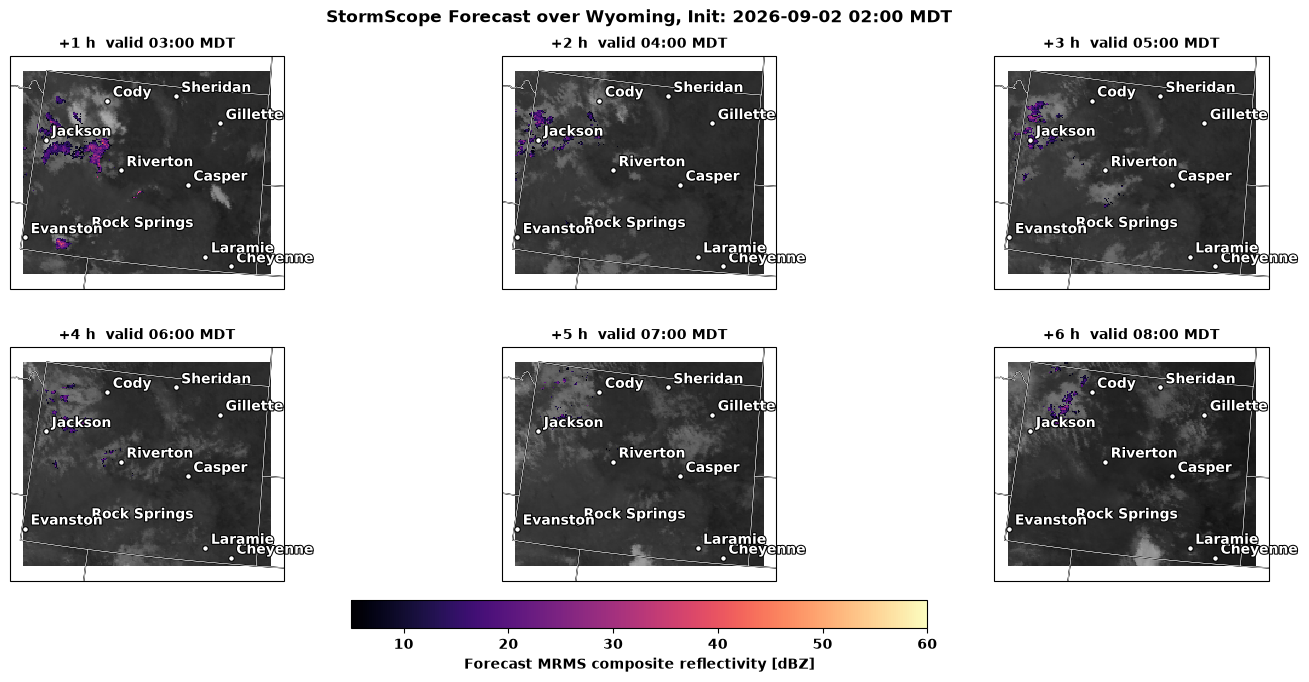

In [53]:
import pandas as pd

steps_per_hour = 60 // STEP_MINUTES
hourly_steps = [k for k in range(N_STEPS) if (k + 1) % steps_per_hour == 0]

# --- convert valid times UTC -> Mountain Time ---
LOCAL_TZ = "America/Denver"   # Wyoming is Mountain Time
valid_local = (
    pd.to_datetime(valid_times)
    .tz_localize("UTC")
    .tz_convert(LOCAL_TZ)
)
init_local = pd.Timestamp(INIT_TIME).tz_localize("UTC").tz_convert(LOCAL_TZ)
tz_abbr = valid_local[0].strftime("%Z")   # "MDT" or "MST" automatically

# --- align lon/lat to the forecast grid (center-crop the halo) ---
nj, ni = wy_ir.shape[1], wy_ir.shape[2]           # 168, 205
dj = (wy_lon.shape[0] - nj) // 2                   # 12
di = (wy_lon.shape[1] - ni) // 2                   # 11
wy_lon_c = wy_lon[dj:dj + nj, di:di + ni]
wy_lat_c = wy_lat[dj:dj + nj, di:di + ni]

ncol = 3
nrow = int(np.ceil(len(hourly_steps) / ncol))
fig, axes = plt.subplots(
    nrow, ncol, figsize=(5 * ncol, 3.9 * nrow),
    subplot_kw=dict(projection=proj_hrrr),
    gridspec_kw=dict(wspace=0.08, hspace=0.25),   # space between boxes
)
fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.10)
axes_flat = np.atleast_1d(axes).ravel()
for ax, k in zip(axes_flat, hourly_steps):
    im, im2 = plot_goes_mrms(
        ax, wy_lon_c, wy_lat_c, wy_ir[k], wy_refc[k],
        f"+{(k + 1) // steps_per_hour} h  valid {valid_local[k]:%H:%M} {tz_abbr}",
    )
    ax.set_extent(WY_EXTENT, crs=ccrs.PlateCarree())
    add_cities(ax, fontsize=10)
for ax in axes_flat[len(hourly_steps):]:
    ax.set_visible(False)
fig.suptitle(
    f"StormScope Forecast over Wyoming, Init: {init_local:%Y-%m-%d %H:%M} {tz_abbr}",
    y=0.98,
)
fig.colorbar(im2, ax=list(axes_flat), orientation="horizontal", shrink=0.4, pad=0.03,
             label="Forecast MRMS composite reflectivity [dBZ]")
plt.savefig("outputs/wyoming_hourly.png", dpi=150, bbox_inches="tight")
plt.show()

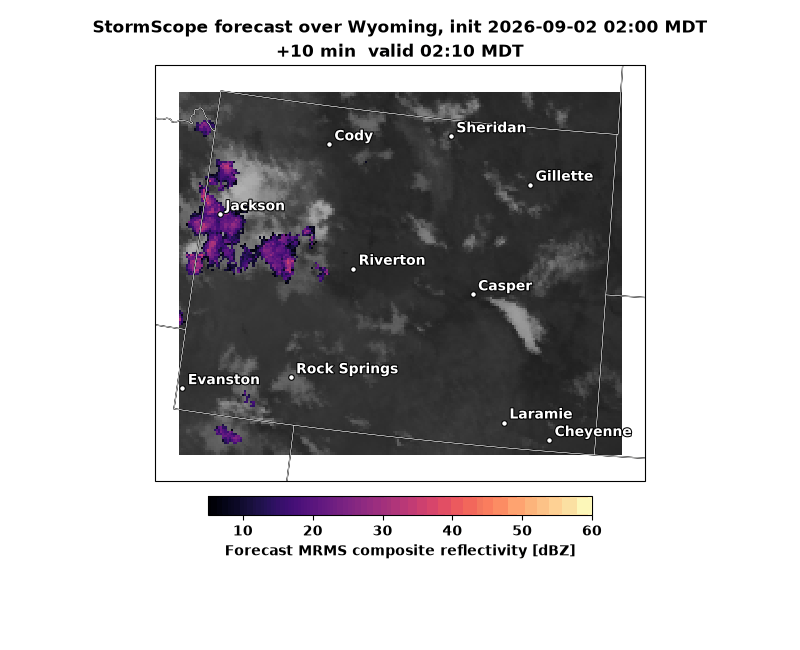

In [54]:
import pandas as pd
import matplotlib.animation as animation
from IPython.display import Video, Image, display
import os

# --- convert valid times UTC -> Mountain Time ---
LOCAL_TZ = "America/Denver"
valid_local = (
    pd.to_datetime(valid_times)
    .tz_localize("UTC")
    .tz_convert(LOCAL_TZ)
)
init_local = pd.Timestamp(INIT_TIME).tz_localize("UTC").tz_convert(LOCAL_TZ)
tz_abbr = valid_local[0].strftime("%Z")

# --- align lon/lat to the forecast grid (center-crop the halo) ---
nj, ni = wy_ir.shape[1], wy_ir.shape[2]
dj = (wy_lon.shape[0] - nj) // 2
di = (wy_lon.shape[1] - ni) // 2
wy_lon_c = wy_lon[dj:dj + nj, di:di + ni]
wy_lat_c = wy_lat[dj:dj + nj, di:di + ni]

# --- single-panel figure, animate every step ---
fig, ax = plt.subplots(figsize=(8, 6.5), subplot_kw=dict(projection=proj_hrrr))
fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.12)

im, im2 = plot_goes_mrms(
    ax, wy_lon_c, wy_lat_c, wy_ir[0], wy_refc[0],
    f"+{STEP_MINUTES} min  valid {valid_local[0]:%H:%M} {tz_abbr}",
)
ax.set_extent(WY_EXTENT, crs=ccrs.PlateCarree())
add_cities(ax, fontsize=10)   # was 7
fig.suptitle(
    f"StormScope forecast over Wyoming, init {init_local:%Y-%m-%d %H:%M} {tz_abbr}",
    y=0.97,
)
fig.colorbar(im2, ax=ax, orientation="horizontal", shrink=0.5, pad=0.03,
             label="Forecast MRMS composite reflectivity [dBZ]")

def update(k):
    im.set_array(wy_ir[k].ravel())
    refc_masked = np.where(wy_refc[k] <= 5, np.nan, wy_refc[k])
    im2.set_array(refc_masked.ravel())
    lead_min = (k + 1) * STEP_MINUTES
    ax.set_title(f"+{lead_min} min  valid {valid_local[k]:%H:%M} {tz_abbr}")
    return im, im2

anim = animation.FuncAnimation(fig, update, frames=N_STEPS, blit=False)

movie_path = None
anim.save("outputs/wyoming_forecast.gif", writer=animation.PillowWriter(fps=3), dpi=100)
movie_path = "outputs/wyoming_forecast.gif"

plt.close(fig)

# --- embed in the notebook ---
if movie_path.endswith(".mp4"):
    display(Video(movie_path, embed=True, width=700))
else:
    display(Image(movie_path, width=700))

![Wyoming StormScope forecast animation](https://github.com/negin513/wyoming-ai-forecast/blob/main/outputs/wyoming_forecast.gif)

## Verification against observed MRMS over Wyoming

Fetch the observed composite reflectivity at each valid time, regrid it with the MRMS model's own
nearest-neighbour interpolator so both fields live on the same grid, and compare inside the
Wyoming box. This is a single deterministic sample, so treat the numbers as a sanity check, not a
skill score.


In [ ]:
lead_times = np.array([(k + 1) * STEP_MINUTES for k in range(N_STEPS)], dtype="timedelta64[m]")

x_obs, c_obs = fetch_data(mrms, time=start_date, variable=np.array(["refc"]), lead_time=lead_times, device=device)
x_obs = model_mrms.input_interp(x_obs.to(torch.float32))          # -> [T, L, C, H, W] on the model grid
mrms_obs = torch.where(model_mrms.valid_mask, x_obs, torch.nan)[0, :, 0].detach().cpu().numpy()  # [N_STEPS, H, W]
mrms_obs_wy = mrms_obs[:, wy_slice[0], wy_slice[1]]                # [N_STEPS, H_wy, W_wy]


def box_stats(field):
    v = field[wy_mask_crop]
    v = v[np.isfinite(v)]
    if v.size == 0:
        return dict(max_dBZ=np.nan, frac_ge35=np.nan, frac_ge20=np.nan)
    return dict(max_dBZ=float(np.nanmax(v)), frac_ge35=float(np.mean(v >= 35)), frac_ge20=float(np.mean(v >= 20)))


rows = []
for k in range(N_STEPS):
    f, o = box_stats(wy_refc[k]), box_stats(mrms_obs_wy[k])
    rows.append(dict(
        lead_min=(k + 1) * STEP_MINUTES, valid=str(valid_times[k])[:16],
        fc_max=f["max_dBZ"], obs_max=o["max_dBZ"],
        fc_frac_ge35=f["frac_ge35"], obs_frac_ge35=o["frac_ge35"],
        fc_frac_ge20=f["frac_ge20"], obs_frac_ge20=o["frac_ge20"],
    ))
verif = pd.DataFrame(rows).set_index("lead_min")
verif.round(3)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
h = verif.index.values / 60.0  # lead time in hours
for ax, col, ylabel in [(axes[0], "frac_ge20", "Fraction of Wyoming with refc >= 20 dBZ"),
                        (axes[1], "max_dBZ", "Max composite reflectivity in Wyoming [dBZ]")]:
    fc_col, obs_col = (f"fc_{col}", f"obs_{col}") if col != "max_dBZ" else ("fc_max", "obs_max")
    ax.plot(h, verif[fc_col], color="#2a78d6", linewidth=2, marker="o", markersize=3, label="StormScope forecast")
    ax.plot(h, verif[obs_col], color="#eb6834", linewidth=2, marker="o", markersize=3, label="MRMS observed")
    ax.set_xlabel("Lead time [h]"); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False)
fig.suptitle("Wyoming box: forecast vs observed reflectivity")
plt.tight_layout(); plt.savefig("outputs/wyoming_verification.png", dpi=150); plt.show()

In [ ]:
# Side-by-side forecast vs observed reflectivity over Wyoming at the final step
k = N_STEPS - 1
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), subplot_kw=dict(projection=proj_hrrr))
for ax, field, name in [(axes[0], wy_refc[k], "StormScope forecast"), (axes[1], mrms_obs_wy[k], "MRMS observed")]:
    im2 = ax.pcolormesh(wy_lon, wy_lat, np.where(field <= 5, np.nan, field), transform=ccrs.PlateCarree(),
                         cmap="magma", shading="auto", vmin=5, vmax=60)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.8)
    ax.set_extent(WY_EXTENT, crs=ccrs.PlateCarree())
    add_cities(ax, color="black", edge="white", fontsize=7)
    ax.set_title(f"{name}, valid {str(valid_times[k])[:16]} UTC (+{(k + 1) * STEP_MINUTES // 60} h)", fontsize=10)
fig.colorbar(im2, ax=axes, orientation="horizontal", shrink=0.4, pad=0.04, label="Composite reflectivity [dBZ]")
plt.savefig("outputs/wyoming_fc_vs_obs.png", dpi=150); plt.show()

## Export the Wyoming cut-out

Save the Wyoming-cropped forecast (GOES IR, forecast + observed reflectivity, GLM lightning
density) to NetCDF for downstream analysis.


## Where to go from here

* **Different case**: pick a different `INIT_TIME` (any historical date with GOES/MRMS/GLM
  coverage works) to nowcast a different storm mode — e.g. a nocturnal MCS vs. a Front Range
  supercell day.
* **Longer / shorter horizon**: adjust `NOWCAST_HOURS` to trade off GPU time against how far into
  the future you trust a pure-observation nowcast to remain skillful.


## 📚 References

* 📄 **Reference**
  * [StormScope (arXiv:2601.17268)](https://arxiv.org/html/2601.17268v1) — the paper behind the observation-to-observation nowcasting model used in this notebook
  * [Earth2Studio docs](https://nvidia.github.io/earth2studio/) — the inference framework providing `StormScopeGOES`/`StormScopeMRMS`, and the GOES/MRMS/GLM data sources used throughout
  * [Earth2Studio (code)](https://github.com/NVIDIA/earth2studio) — source repository
* 🙋 **Ask for help**
  * [Earth2Studio GitHub issues](https://github.com/NVIDIA/earth2studio/issues) for bug reports and feature requests
